# Painel: Estados da Rede + Probabilidades de Convergência

Notebook pronto para rodar — todo o código está nas células abaixo (sem precisar de arquivos `.py` externos).

**O que você precisa fazer:** só ajustar o caminho do CSV na célula "CONFIGURAÇÃO" perto do final e rodar todas as células em ordem (`Cell > Run All`).

Bibliotecas necessárias: `matplotlib`, `pandas`, `pillow`. Se alguma faltar, descomente e rode a célula de instalação abaixo.


In [ ]:
# Descomente se precisar instalar as dependências
# %pip install matplotlib pandas pillow


## Parte 1 — gráfico de "node states" (dot-matrix)

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import pandas as pd

# --------------------------------------------------------------------------
# 1. COLOR PALETTE  (pixel-sampled from the reference figure's own legend)
# --------------------------------------------------------------------------
COLOR_ACTIVE              = "#2C5498"  # navy blue    -> Active Node (1)
EDGE_ACTIVE               = "#1F3D73"  # darker navy edge on the same marker

COLOR_INACTIVE            = "#EAF3FB"  # pale blue    -> Inactive Node (0)
EDGE_INACTIVE             = "#7FB4E0"  # medium blue edge

COLOR_INPUT_ACTIVE        = "#3F9E88"  # teal green   -> Input Node (Active)
EDGE_INPUT                = "#2C6B5C"  # darker teal edge

COLOR_PHENOTYPE_ACTIVE    = "#C05820"  # rust orange  -> Output Phenotype (Active)
EDGE_PHENOTYPE_ACTIVE     = "#9C4417"  # darker rust edge

COLOR_PHENOTYPE_INACTIVE  = "#FFFDF7"  # off-white    -> Output Phenotype (Inactive)
EDGE_PHENOTYPE_INACTIVE   = "#E8A644"  # golden-orange ring

EDGE_DEFAULT              = EDGE_INACTIVE
BAND_A                    = "#FFFFFF"
BAND_B                    = "#FFFFFF"
PANEL_PHENOTYPE           = "#F7E6CF"
TITLE_COLOR               = "#2E6B50"
OUTCOME_LABEL_COLOR       = "#C05820"

LABEL_FONTSIZE = 7.8
_CHAR_SIZE_PER_PT = 0.155 / 7.8


def _label_band_height(names, rotation_deg, fontsize=LABEL_FONTSIZE, gap=0.3, pad=0.25):
    """Vertical space (data units) a band of rotated column labels needs."""
    import math
    if not names:
        return gap + pad
    max_len = max(len(n) for n in names)
    char_size = _CHAR_SIZE_PER_PT * fontsize
    vertical_extent = max_len * char_size * abs(math.sin(math.radians(rotation_deg)))
    return gap + vertical_extent + pad


def _marker_style(value, is_input, is_phenotype):
    """Return the matplotlib Circle kwargs for one cell, given its role."""
    if is_input:
        facecolor = COLOR_INPUT_ACTIVE if value else COLOR_INACTIVE
        edgecolor = EDGE_INPUT if value else EDGE_INACTIVE
        linewidth = 1.4
    elif is_phenotype:
        facecolor = COLOR_PHENOTYPE_ACTIVE if value else COLOR_PHENOTYPE_INACTIVE
        edgecolor = EDGE_PHENOTYPE_ACTIVE if value else EDGE_PHENOTYPE_INACTIVE
        linewidth = 2.0
    else:
        facecolor = COLOR_ACTIVE if value else COLOR_INACTIVE
        edgecolor = EDGE_ACTIVE if value else EDGE_INACTIVE
        linewidth = 1.2
    return dict(facecolor=facecolor, edgecolor=edgecolor, linewidth=linewidth)


def plot_boolean_states(
    df,
    input_nodes,
    phenotype_nodes,
    title,
    out_path="network_states.png",
    dpi=200,
    show_top_labels=True,
    show_bottom_labels=True,
    top_label_rotation=60,
    bottom_label_rotation=45,
    row_label_colors=None,
):
    """Draw the dot-matrix figure: one row per state, one column per node."""
    n_rows, n_cols = df.shape
    node_names = list(df.columns)
    row_labels = list(df.index)

    row_h = 1.0
    col_w = 1.0
    left_margin = 2.6
    right_pad = 0.6
    plot_w = left_margin + n_cols * col_w + right_pad

    h_title = 0.8
    h_legend = 0.75
    h_outcome_label = 0.7 if phenotype_nodes else 0.0
    h_headers = (_label_band_height(node_names, top_label_rotation)
                 if show_top_labels else 0.35)
    h_rows = n_rows * row_h
    h_bottom_headers = (_label_band_height(node_names, bottom_label_rotation)
                         if show_bottom_labels else 0.0)
    bottom_pad = 0.15

    plot_h = (h_title + h_legend + h_outcome_label + h_headers + h_rows
              + h_bottom_headers + bottom_pad)

    y_fig_top   = plot_h
    y_title     = y_fig_top - h_title
    y_legend    = y_title - h_legend
    y_outcome   = y_legend - h_outcome_label
    y_header_top = y_outcome
    y_rows_top  = y_header_top - h_headers
    y_rows_bot  = y_rows_top - h_rows

    fig, ax = plt.subplots(figsize=(plot_w * 0.42, plot_h * 0.42))
    ax.set_xlim(0, plot_w)
    ax.set_ylim(0, plot_h)
    ax.set_aspect("equal")
    ax.axis("off")

    if phenotype_nodes:
        first_idx = node_names.index(phenotype_nodes[0])
        panel_x0 = left_margin + first_idx * col_w - 0.08
        panel_w = len(phenotype_nodes) * col_w + 0.16
        ax.add_patch(Rectangle((panel_x0, y_rows_bot), panel_w, y_rows_top - y_rows_bot,
                                facecolor=PANEL_PHENOTYPE, edgecolor="none", zorder=0))
        ax.text(panel_x0 + panel_w / 2, y_outcome + 0.05, "OUTCOME PHENOTYPES",
                fontsize=9, fontweight="bold", color=OUTCOME_LABEL_COLOR,
                ha="center", va="bottom")

    for r in range(n_rows):
        y0 = y_rows_top - (r + 1) * row_h
        ax.add_patch(Rectangle((0, y0), plot_w, row_h,
                                facecolor=BAND_A if r % 2 == 0 else BAND_B,
                                edgecolor="none", zorder=0.5))

    ax.text(0.1, y_header_top - 0.1, "Name", fontsize=10, fontweight="bold", ha="left", va="top")
    row_label_colors = row_label_colors or {}
    for r, label in enumerate(row_labels):
        y_center = y_rows_top - r * row_h - row_h / 2
        color = row_label_colors.get(label, "#000000")
        ax.text(0.1, y_center, str(label), fontsize=9, fontweight="bold",
                ha="left", va="center", color=color)

    ax.plot([0, plot_w], [y_rows_top, y_rows_top], color="#B0B0B0", linewidth=1, zorder=2)

    if show_top_labels:
        for c, name in enumerate(node_names):
            x_center = left_margin + c * col_w + col_w / 2
            weight = "bold" if name in phenotype_nodes or name in input_nodes else "normal"
            ax.text(x_center, y_rows_top + 0.15, name, fontsize=LABEL_FONTSIZE,
                    rotation=top_label_rotation, rotation_mode="anchor",
                    ha="left", va="bottom", fontweight=weight)

    radius = 0.34
    for r, (_, row) in enumerate(df.iterrows()):
        y_center = y_rows_top - r * row_h - row_h / 2
        for c, name in enumerate(node_names):
            x_center = left_margin + c * col_w + col_w / 2
            value = int(row[name])
            style = _marker_style(value, is_input=name in input_nodes,
                                   is_phenotype=name in phenotype_nodes)
            ax.add_patch(Circle((x_center, y_center), radius, zorder=3, **style))

    if show_bottom_labels:
        ax.plot([0, plot_w], [y_rows_bot, y_rows_bot], color="#B0B0B0", linewidth=1, zorder=2)
        for c, name in enumerate(node_names):
            x_center = left_margin + c * col_w + col_w / 2
            weight = "bold" if name in phenotype_nodes or name in input_nodes else "normal"
            ax.text(x_center, y_rows_bot - 0.15, name, fontsize=LABEL_FONTSIZE,
                    rotation=-bottom_label_rotation, rotation_mode="anchor",
                    ha="left", va="top", fontweight=weight)

    legend_items = [
        ("Active Node (1)", COLOR_ACTIVE, EDGE_ACTIVE, 1.2),
        ("Inactive Node (0)", COLOR_INACTIVE, EDGE_INACTIVE, 1.2),
        ("Input Node (Active)", COLOR_INPUT_ACTIVE, EDGE_INPUT, 1.4),
        ("Output Phenotype (Active)", COLOR_PHENOTYPE_ACTIVE, EDGE_PHENOTYPE_ACTIVE, 2.0),
        ("Output Phenotype (Inactive)", COLOR_PHENOTYPE_INACTIVE, EDGE_PHENOTYPE_INACTIVE, 2.0),
    ]
    ax.text(left_margin, y_legend + h_legend - 0.05, "LEGEND & NODE BINARY STATES",
            fontsize=9, fontweight="bold", ha="left", va="top")
    legend_y = y_legend + 0.15
    renderer = fig.canvas.get_renderer()
    lx = left_margin
    for label, fc, ec, lw in legend_items:
        ax.add_patch(Circle((lx, legend_y), 0.15, facecolor=fc, edgecolor=ec, linewidth=lw, zorder=4))
        txt = ax.text(lx + 0.28, legend_y, label, fontsize=8.3, ha="left", va="center")
        bbox = txt.get_window_extent(renderer=renderer)
        bbox_data = bbox.transformed(ax.transData.inverted())
        text_width = bbox_data.x1 - bbox_data.x0
        lx += 0.28 + text_width + 0.55

    ax.text(left_margin, y_fig_top - 0.05, title, fontsize=13, fontweight="bold",
            color=TITLE_COLOR, ha="left", va="top")

    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"Saved: {out_path}")


## Parte 2 — gráfico de barras de probabilidade dos estados estáveis

In [2]:
import csv

# --------------------------------------------------------------------------
# 1. Parse do CSV MonteCarlo do GINsim
# --------------------------------------------------------------------------
def parse_ginsim_montecarlo_csv(path):
    """Retorna (node_names, lista de dicts) com um dict por estado estavel."""
    with open(path, encoding="utf-8-sig") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith(",") and ",prob,depth" in line:
            header_idx = i
            break
    if header_idx is None:
        raise ValueError("Nao encontrei a linha de cabecalho dos estados estaveis ('...,prob,depth').")

    header = next(csv.reader([lines[header_idx]]))
    node_names = header[1:-2]

    states = []
    for line in lines[header_idx + 1:]:
        if not line.strip():
            break
        row = next(csv.reader([line]))
        if not row or not row[0].startswith("SS"):
            break
        state_id = row[0]
        values = {name: int(v) for name, v in zip(node_names, row[1:-2])}
        prob = float(row[-2])
        depth_field = row[-1]
        if "+-" in depth_field:
            depth_mean, depth_std = depth_field.split("+-")
        else:
            depth_mean, depth_std = depth_field, "0"
        active_nodes = [n for n, v in values.items() if v == 1]
        states.append(dict(id=state_id, values=values, prob=prob,
                            depth_mean=float(depth_mean), depth_std=float(depth_std),
                            active_nodes=active_nodes))
    return node_names, states


def label_by_phenotype(states, phenotype_nodes):
    """Rotulo curto por fenotipo ativo, ex. 'Resistance' ou 'Proliferation + Resistance'."""
    labels = []
    for s in states:
        active_phenotypes = [p for p in phenotype_nodes if s["values"].get(p) == 1]
        if active_phenotypes:
            nice = [p.replace("_", " ").capitalize() for p in active_phenotypes]
            labels.append(" + ".join(nice))
        else:
            labels.append(s["id"])
    return labels


# --------------------------------------------------------------------------
# 2. Paleta categorica (validada com o validador do skill de dataviz)
# --------------------------------------------------------------------------
# Atribuida pela POSICAO de cada coluna de fenotipo em `phenotype_nodes`,
# NAO pelo texto do rotulo gerado ("Cell cycle arrest", "Senescence", ...).
# Combinar por texto e fragil: label_by_phenotype monta a string a partir
# do nome literal da coluna (troca "_" por espaco e da .capitalize()), entao
# um dicionario fixo por texto cai em cinza (fallback) assim que o modelo usa
# um nome de fenotipo diferente ou com grafia/maiuscula ligeiramente distinta.
# Atribuir pela posicao da coluna resolve isso de vez: qualquer nome de
# fenotipo sempre recebe uma cor estavel e distinta.
CATEGORICAL_PALETTE = ["#2C5498", "#C05820", "#1E9E7C", "#8E5BA6", "#B08A00"]
FALLBACK_COLOR = "#8C8C8C"  # usado so se um estado nao tiver NENHUM fenotipo ativo
TEXT_PRIMARY = "#2B2B2B"
TEXT_MUTED = "#7A7A7A"
GRID_COLOR = "#E3E3E1"


def build_phenotype_color_map(phenotype_nodes):
    """{nome da coluna de fenotipo -> cor}, atribuida por posicao fixa."""
    return {
        node: CATEGORICAL_PALETTE[i % len(CATEGORICAL_PALETTE)]
        for i, node in enumerate(phenotype_nodes)
    }


def state_color(state, phenotype_nodes, color_map):
    """Cor de um estado = cor do primeiro fenotipo ativo (na ordem de
    phenotype_nodes). Para um estado com mais de um fenotipo ativo (ex.
    PROLIFERATION e RESISTANCE juntos), usa o que vier primeiro em
    phenotype_nodes, entao a combinacao sempre casa com o fenotipo dominante."""
    for node in phenotype_nodes:
        if state["values"].get(node) == 1:
            return color_map[node]
    return FALLBACK_COLOR


from matplotlib.patches import FancyBboxPatch


def plot_state_probabilities(states, labels, phenotype_nodes, title, subtitle="",
                              out_path="state_probabilities.png", dpi=200):
    order = sorted(range(len(states)), key=lambda i: states[i]["prob"], reverse=True)
    states = [states[i] for i in order]
    labels = [labels[i] for i in order]

    color_map = build_phenotype_color_map(phenotype_nodes)

    n = len(states)
    fig_h = 0.9 + n * 0.62
    fig, ax = plt.subplots(figsize=(8.5, fig_h))

    y_positions = list(range(n))[::-1]
    bar_height = 0.55

    max_pct = max(s["prob"] for s in states) * 100
    ax.set_xlim(0, max_pct * 1.28)

    for y, s, label in zip(y_positions, states, labels):
        color = state_color(s, phenotype_nodes, color_map)
        pct = s["prob"] * 100
        rounding = 0.045
        ax.add_patch(FancyBboxPatch((0, y - bar_height / 2), pct, bar_height,
                     boxstyle=f"round,pad=0,rounding_size={rounding}",
                     linewidth=0, facecolor=color, mutation_aspect=1))
        ax.text(pct + max_pct * 0.02, y, f"{pct:.1f}%", va="center", ha="left",
                fontsize=10.5, fontweight="bold", color=TEXT_PRIMARY)
        ax.text(-max_pct * 0.02, y, label, va="center", ha="right",
                fontsize=10.5, color=TEXT_PRIMARY)
        ax.text(-max_pct * 0.02, y - 0.30,
                f"{s['id']} \u00b7 depth {s['depth_mean']:.0f}\u00b1{s['depth_std']:.0f}",
                va="center", ha="right", fontsize=8, color=TEXT_MUTED)

    ax.set_ylim(-0.8, n - 0.2)
    ax.set_yticks([])
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOR)

    ax.set_xlabel("Probability of convergence (% of Monte Carlo runs)", fontsize=9.5, color=TEXT_MUTED)
    ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")
    ax.tick_params(axis="x", colors=TEXT_MUTED, labelsize=9)
    ax.grid(axis="x", color=GRID_COLOR, linewidth=1, zorder=0)
    ax.set_axisbelow(True)

    ax.set_title(title, fontsize=14, fontweight="bold", color=TEXT_PRIMARY, loc="left", pad=26)
    if subtitle:
        ax.text(0, 1.045, subtitle, transform=ax.transAxes, fontsize=9.5,
                color=TEXT_MUTED, ha="left", va="bottom")

    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"Saved: {out_path}")


## Parte 3 — juntar as duas figuras em um painel só

In [3]:
import os
import tempfile
from PIL import Image, ImageDraw, ImageFont


def _matplotlib_font_dir():
    """matplotlib ships its own copy of DejaVu Sans on every OS (it needs it
    to render plot text), so this is a much more reliable source than
    guessing OS-specific system-font paths - and matplotlib is already a
    hard dependency of this notebook."""
    try:
        import matplotlib
        return os.path.join(matplotlib.get_data_path(), "fonts", "ttf")
    except Exception:
        return None


_MPL_FONT_DIR = _matplotlib_font_dir()

# tenta a fonte embutida do matplotlib primeiro (sempre presente, em
# qualquer SO), depois caminhos comuns de SO, e por ultimo o fallback do
# PIL - nessa ordem, para nao depender de fontes do sistema estarem instaladas
_FONT_CANDIDATES_BOLD = [p for p in [
    os.path.join(_MPL_FONT_DIR, "DejaVuSans-Bold.ttf") if _MPL_FONT_DIR else None,
    "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",   # Linux
    "/Library/Fonts/Arial Bold.ttf",                           # macOS
    "/System/Library/Fonts/Supplemental/Arial Bold.ttf",       # macOS
    "C:\\Windows\\Fonts\\arialbd.ttf",                    # Windows
] if p]
_FONT_CANDIDATES_REGULAR = [p for p in [
    os.path.join(_MPL_FONT_DIR, "DejaVuSans.ttf") if _MPL_FONT_DIR else None,
    "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    "/Library/Fonts/Arial.ttf",
    "/System/Library/Fonts/Supplemental/Arial.ttf",
    "C:\\Windows\\Fonts\\arial.ttf",
] if p]


def _load_font(candidates, size):
    for path in candidates:
        if os.path.exists(path):
            try:
                return ImageFont.truetype(path, size)
            except Exception:
                continue
    # ultimo recurso: fonte embutida do PIL. Em versoes antigas do Pillow
    # ela IGNORA o `size` (fica sempre ~10px, minuscula) - por isso
    # tentamos a variante com tamanho (Pillow >= 10.1) antes de cair na
    # antiga sem tamanho.
    try:
        return ImageFont.load_default(size=size)
    except TypeError:
        return ImageFont.load_default()


def _pad_to_width(im, target_w, bg=(255, 255, 255)):
    if im.width >= target_w:
        return im
    canvas = Image.new("RGB", (target_w, im.height), bg)
    x = (target_w - im.width) // 2
    canvas.paste(im, (x, 0))
    return canvas


def stitch_vertical(image_paths, out_path, gap=None, bg=(255, 255, 255),
                     panel_title=None, panel_subtitle=None,
                     panel_labels=True, label_font_size=None, label_pad=None):
    """Empilha os PNGs na vertical, centralizando os mais estreitos.

    panel_labels: True desenha "A", "B", "C"... em negrito no canto
    superior esquerdo de cada sub-figura (padrao de figura cientifica
    multi-painel); aceita uma lista de strings para rotulos customizados,
    ou False para desligar.

    gap / label_font_size / label_pad: deixe em None (padrao) para que o
    tamanho seja calculado proporcionalmente a largura final do painel,
    em vez de um numero fixo de pixels. Os graficos internos (states.png,
    probs.png) sao renderizados pelo matplotlib em dpi=200, entao os
    titulos/eixos deles ja saem grandes em pixels; um titulo/rotulo A-B
    com tamanho fixo pequeno fica minusculo perto disso assim que o painel
    fica largo (uma rede com 30+ nos facilmente passa de 2000px de
    largura) - por isso escalamos pelo `target_w`.
    """
    images = [Image.open(p).convert("RGB") for p in image_paths]
    target_w = max(im.width for im in images)
    images = [_pad_to_width(im, target_w, bg) for im in images]

    # tamanhos proporcionais (em px), com um piso minimo para paineis estreitos
    if gap is None:
        gap = max(28, round(target_w * 0.013))
    if label_font_size is None:
        label_font_size = max(28, round(target_w * 0.024))
    if label_pad is None:
        label_pad = max(12, round(target_w * 0.009))

    title_font_size = max(22, round(target_w * 0.021))
    subtitle_font_size = max(14, round(target_w * 0.012))
    title_pad_top = max(8, round(target_w * 0.006))
    line_gap = max(6, round(target_w * 0.004))

    header_h = 0
    if panel_title:
        header_h = title_pad_top + title_font_size + line_gap
        if panel_subtitle:
            header_h += subtitle_font_size + line_gap
        header_h += line_gap  # respiro antes da primeira sub-figura

    total_h = header_h + sum(im.height for im in images) + gap * (len(images) - 1)
    canvas = Image.new("RGB", (target_w, total_h), bg)
    draw = ImageDraw.Draw(canvas)

    if panel_title:
        title_font = _load_font(_FONT_CANDIDATES_BOLD, title_font_size)
        subtitle_font = _load_font(_FONT_CANDIDATES_REGULAR, subtitle_font_size)
        y_text = title_pad_top
        draw.text((label_pad, y_text), panel_title, fill="#2B2B2B", font=title_font)
        y_text += title_font_size + line_gap
        if panel_subtitle:
            draw.text((label_pad, y_text), panel_subtitle, fill="#7A7A7A", font=subtitle_font)

    if panel_labels is True:
        labels = [chr(ord("A") + i) for i in range(len(images))]
    elif panel_labels:
        labels = list(panel_labels)
    else:
        labels = None

    label_font = _load_font(_FONT_CANDIDATES_BOLD, label_font_size)

    y = header_h
    for i, im in enumerate(images):
        canvas.paste(im, (0, y))
        if labels:
            draw.text((label_pad, y + label_pad), labels[i], fill="#000000", font=label_font)
        y += im.height + gap

    canvas.save(out_path)
    print(f"Saved panel: {out_path}")


def build_panel(csv_path, input_nodes, phenotype_nodes, panel_title,
                 panel_subtitle="", out_path="network_panel.png", panel_labels=True):
    node_names, states = parse_ginsim_montecarlo_csv(csv_path)
    labels = label_by_phenotype(states, phenotype_nodes)

    order = sorted(range(len(states)), key=lambda i: states[i]["prob"], reverse=True)
    states_sorted = [states[i] for i in order]
    labels_sorted = [labels[i] for i in order]

    row_labels = [s["id"] for s in states_sorted]
    data = {row_labels[i]: [states_sorted[i]["values"][n] for n in node_names]
            for i in range(len(states_sorted))}
    df = pd.DataFrame.from_dict(data, orient="index", columns=node_names)

    # cor de cada rotulo de linha = cor do fenotipo dominante daquele estado,
    # atribuida por posicao da coluna (nao pelo texto do rotulo)
    color_map = build_phenotype_color_map(phenotype_nodes)
    row_label_colors = {row_labels[i]: state_color(states_sorted[i], phenotype_nodes, color_map)
                         for i in range(len(row_labels))}

    with tempfile.TemporaryDirectory() as tmp:
        states_png = os.path.join(tmp, "states.png")
        probs_png = os.path.join(tmp, "probs.png")

        plot_boolean_states(df, input_nodes=input_nodes, phenotype_nodes=phenotype_nodes,
                             title="Node States per Stable State", out_path=states_png,
                             show_top_labels=False, show_bottom_labels=True,
                             bottom_label_rotation=45, row_label_colors=row_label_colors)

        plot_state_probabilities(states_sorted, labels_sorted, phenotype_nodes=phenotype_nodes,
                                  title="Probability of Convergence",
                                  subtitle=f"Monte Carlo, N = 1000 runs \u00b7 {len(states_sorted)} stable states reached",
                                  out_path=probs_png)

        stitch_vertical([states_png, probs_png], out_path=out_path,
                         panel_title=panel_title, panel_subtitle=panel_subtitle,
                         panel_labels=panel_labels)


## CONFIGURAÇÃO — ajuste aqui e rode

Troque `CSV_PATH` pelo caminho do seu arquivo (se o `.csv` estiver na mesma pasta do notebook, só o nome do arquivo já basta).

In [4]:
CSV_PATH = "result.csv"   # <-- troque aqui se necessario

INPUT_NODES = ["DDR"]
PHENOTYPE_NODES = ["PROLIFERATION", "RESISTANCE", "CELL_CYCLE_ARREST", "PYROPTOSIS", "APOPTOSIS"]

build_panel(
    CSV_PATH,
    input_nodes=INPUT_NODES,
    phenotype_nodes=PHENOTYPE_NODES,
    panel_title="Pyroptosis / miR204-MALAT1-SIRT Network \u2014 Stable States",
    panel_subtitle="Same 5 attractors in both panels, ordered by probability of convergence",
    out_path="network_panel.png",
)


Saved: /tmp/tmpsizryban/states.png
Saved: /tmp/tmpsizryban/probs.png
Saved panel: network_panel.png


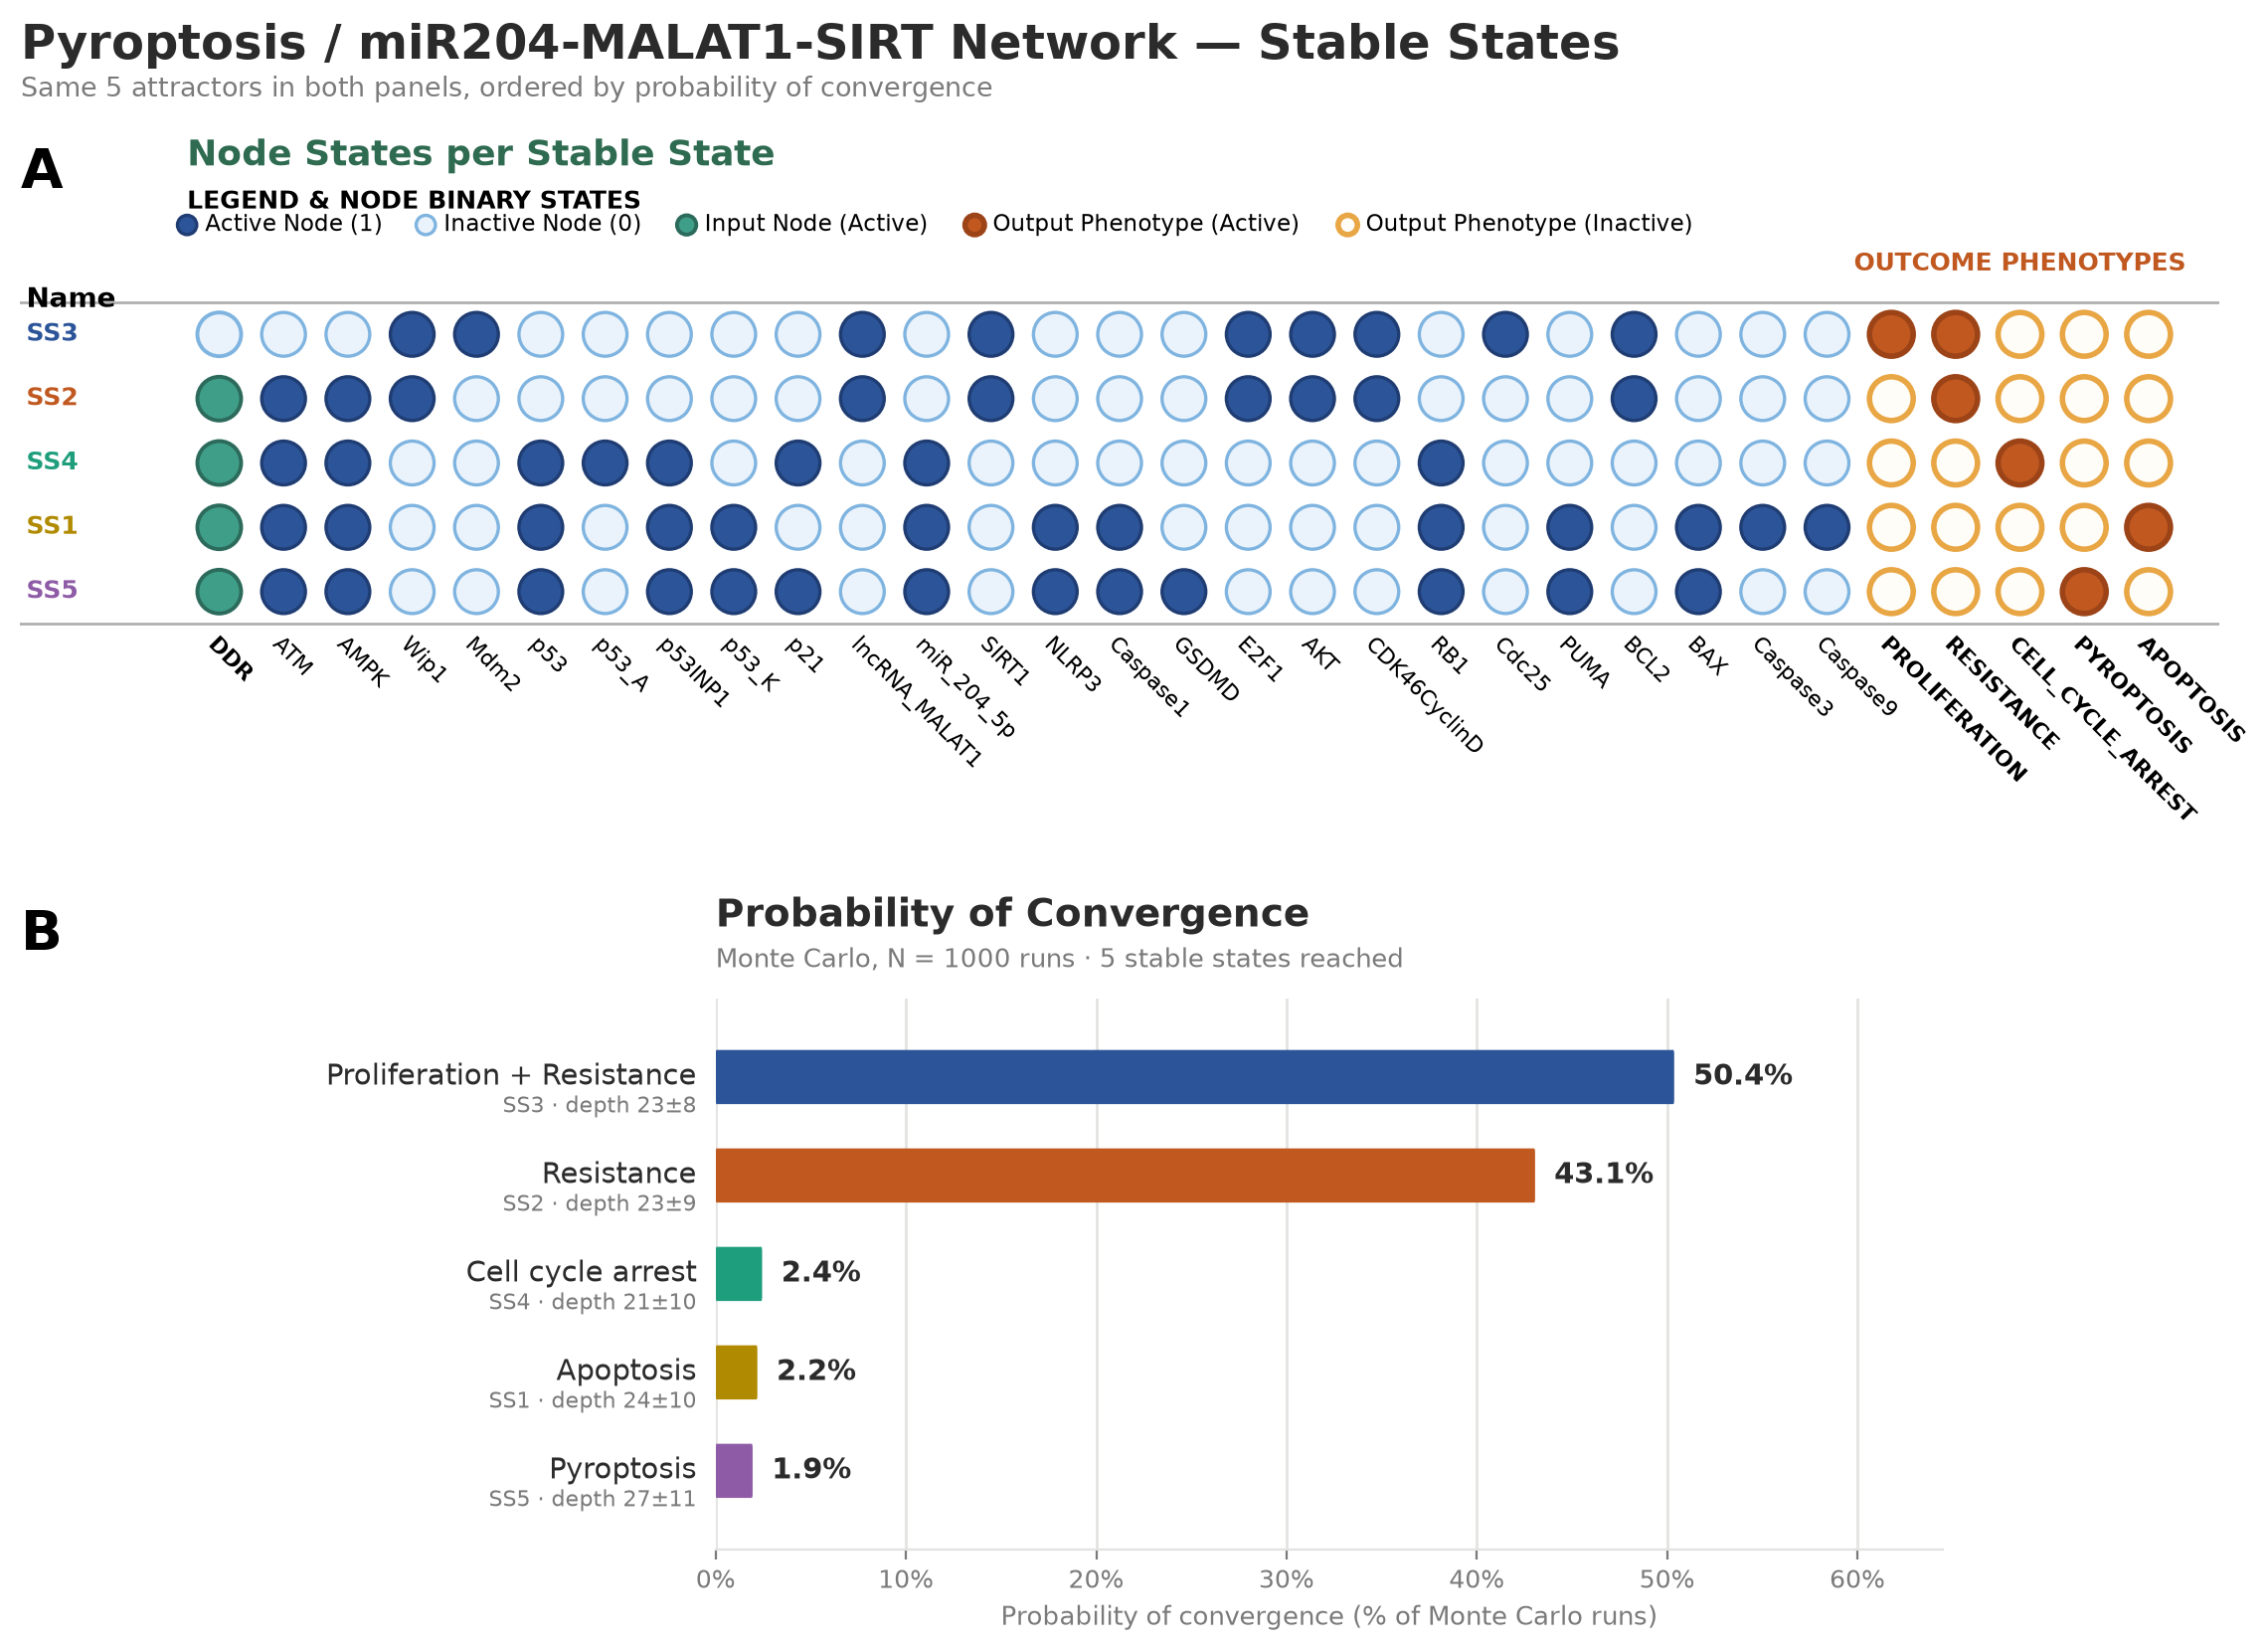

In [5]:
from IPython.display import Image as IPyImage, display

display(IPyImage(filename="network_panel.png"))
